<a href="https://colab.research.google.com/github/leajag/2025_ML_EES/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Packages

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

from __future__ import print_function  # ganz oben

# Common imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# GIS / Raster / Vector
import rasterio
import geopandas as gpd
from osgeo import ogr

# CNN / ML
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.utils import plot_model
from sklearn.model_selection import train_test_split


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

# Pfad zu deinem Projektordner
project_path = '/content/drive/MyDrive/ML_project'

# Verzeichnis wechseln
os.chdir(project_path)

# Inhalt anzeigen
os.listdir()


['d',
 'r',
 'k',
 't',
 'data',
 'data_arrays.npz',
 'data_arrays_rem4.npz',
 'train.npz',
 'val.npz',
 'test.npz',
 'checkpoints_best_only']

In [5]:
#upload data
data = np.load('data_arrays_rem4.npz')
print(data.files)


['X', 'y']


# Data pre-processing

In [52]:
X = data['X']
y = data['y']

In [54]:
#normalization of X
X_norm = X / 255.0

Training / Test split

In [55]:
y_labels = y[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set
print("Unique classes:", np.unique(y_labels))

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=5, stratify=y_labels) #stratify: to ensure, that all classes are in test set

# upper left pixel to adjust labels as for all pixels in one image same class
y_test = y_test[:,0,0]
y_train = y_train[:,0,0]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Unique classes: [1 2 3 5]
X_train shape: (948, 3, 128, 128)
X_test shape: (238, 3, 128, 128)
y_train shape: (948,)
y_test shape: (238,)


# Logistic regression as a baseline model

Data pre-processing

In [82]:
#flatten layer for LR to 2D array
# Flatten X_train from (samples, channels, height, width) to (samples, features)

# Flatten X
X_train_flat = X_train.reshape(len(X_train), -1) #X_train_flat.shape = (6643, 3*128*128) = (6643, 49152) #6643: number of images
X_test_flat  = X_test.reshape(len(X_test), -1)

#testing shapes
print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_flat: (948, 49152)
X_test_flat: (238, 49152)
y_train: (948,)
y_test: (238,)


Logistic regression

In [83]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(multi_class = "multinomial", max_iter=1000, random_state=42) #multinomial: as not binary operation
clf.fit(X_train_flat, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

Evaluation on test set

In [96]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

#prediction on test set
clf_preds_test = clf.predict(X_test_flat)
clf_probs_test = clf.predict_proba(X_test_flat)  # for Loss

#Accuracy
clf_acc_test = accuracy_score(y_test, clf_preds_test)

#Log-Loss (Cross-Entropy)
test_logloss = log_loss(y_test, clf_probs_test)

# Precision, Recall, F1 (weighted für mehrere Klassen)
clf_precision_test = precision_score(y_test, clf_preds_test, average='weighted')
clf_recall_test = recall_score(y_test, clf_preds_test, average='weighted')
clf_f1_test = f1_score(y_test, clf_preds_test, average='weighted')

print(f"Accuracy: {clf_acc_test:.4f}")
print(f"Log-Loss: {test_logloss:.4f}")
print(f"Weighted Precision: {clf_precision_test:.4f}")
print(f"Weighted Recall: {clf_recall_test:.4f}")
print(f"Weighted F1 Score: {clf_f1_test:.4f}")


Accuracy: 0.5294
Log-Loss: 1.3784
Weighted Precision: 0.5415
Weighted Recall: 0.5294
Weighted F1 Score: 0.5292


# Convolutional Neural Networks (CNN)

re-organization of data

In [56]:
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1]) #reorganisation of channels for Keras
# Reorganisation for Keras: transpose X_train and X-test to (batch, height, width, channels)
X_train_trans = np.transpose(X_train, (0, 2, 3, 1))
X_test_trans  = np.transpose(X_test,  (0, 2, 3, 1))

# Re-labeling
label_mapping = {1: 0, 2: 1, 3: 2, 5: 3}
y_train_relabeled = np.vectorize(label_mapping.get)(y_train)
y_test_relabeled  = np.vectorize(label_mapping.get)(y_test)

print("X_train_trans shape:", X_train_trans.shape)
print("X test transe shape:", X_test_trans.shape)
print("y_train_relabeled shape:", y_train_relabeled.shape)
print("y test relabeled shape:", y_test_relabeled.shape)



X_train_trans shape: (948, 128, 128, 3)
X test transe shape: (238, 128, 128, 3)
y_train_relabeled shape: (948,)
y test relabeled shape: (238,)


**Simple baseline model**

In [86]:
model1 = tf.keras.Sequential()
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1]) #reorganisation of channels for Keras
#layers from 6.2 lab
#first layer: 16 filters, a 3x3 kernel size, a ReLU activation function and 'SAME' padding, weights are initialised by providing the input_shape argument in the first layer.
model1.add(tf.keras.layers.Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'))
model1.add(tf.keras.layers.Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'))
model1.add(MaxPooling2D((8,8),name='pool_1'))
model1.add(tf.keras.layers.Flatten(name='flatten'))
model1.add(tf.keras.layers.Dense(32, activation='relu',name='dense_1'))
model1.add(tf.keras.layers.Dense(4,activation='softmax',name='dense_2'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,308 (262.92 KB)

 Trainable params: 67,308 (262.92 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model1.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [93]:
history_model1 = model1.fit(X_train_trans, y_train_relabeled,
                    epochs=30,
                    verbose=1,
                    validation_split=0.2) #validation_split: validation intern


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.6368 - loss: 0.8696 - val_accuracy: 0.7158 - val_loss: 0.7733
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6577 - loss: 0.7801 - val_accuracy: 0.7263 - val_loss: 0.6340
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6543 - loss: 0.7279 - val_accuracy: 0.7789 - val_loss: 0.6422
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7083 - loss: 0.7044 - val_accuracy: 0.8316 - val_loss: 0.5963
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7543 - loss: 0.6472 - val_accuracy: 0.7158 - val_loss: 0.6511
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7006 - loss: 0.6494 - val_accuracy: 0.7053 - val_loss: 0.6181
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7869 - loss: 0.5697 - val_accuracy: 0.8737 - val_loss: 0.5286
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8121 - loss: 0.5166 - val_accuracy: 0.8316 - 

In [98]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# ============================
# 1) TRAINING METRICS
# ============================
y_train_pred = model1.predict(X_train_trans).argmax(axis=1)

train_f1 = f1_score(y_train_relabeled, y_train_pred, average='weighted')
train_precision = precision_score(y_train_relabeled, y_train_pred, average='weighted')
train_recall = recall_score(y_train_relabeled, y_train_pred, average='weighted')

train_loss, train_acc = model1.evaluate(X_train_trans, y_train_relabeled, verbose=0)

print("\n=== TRAIN METRICS ===")
print(f"Train loss: {train_loss:.4f}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Train weighted F1: {train_f1:.4f}")
print(f"Train precision (weighted): {train_precision:.4f}")
print(f"Train recall (weighted): {train_recall:.4f}")

# ============================
# 2) VALIDATION METRICS
# ============================
val_size = int(0.1 * len(X_train_trans))
X_val = X_train_trans[-val_size:]
y_val = y_train_relabeled[-val_size:]

y_val_pred = model1.predict(X_val).argmax(axis=1)

val_f1 = f1_score(y_val, y_val_pred, average='weighted')
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')

val_loss, val_acc = model1.evaluate(X_val, y_val, verbose=0)

print("\n=== VALIDATION METRICS ===")
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation weighted F1: {val_f1:.4f}")
print(f"Validation precision (weighted): {val_precision:.4f}")
print(f"Validation recall (weighted): {val_recall:.4f}")

# ============================
# 3) TEST METRICS
# ============================
y_test_pred = model1.predict(X_test_trans).argmax(axis=1)

test_f1_sm = f1_score(y_test_relabeled, y_test_pred, average='weighted')
test_precision_sm = precision_score(y_test_relabeled, y_test_pred, average='weighted')
test_recall_sm = recall_score(y_test_relabeled, y_test_pred, average='weighted')

test_loss_sm, test_acc_sm = model1.evaluate(X_test_trans, y_test_relabeled, verbose=0)

print("\n=== TEST METRICS ===")
print(f"Test loss: {test_loss_sm:.4f}")
print(f"Test accuracy: {test_acc_sm:.4f}")
print(f"Test weighted F1: {test_f1_sm:.4f}")
print(f"Test precision (weighted): {test_precision_sm:.4f}")
print(f"Test recall (weighted): {test_recall_sm:.4f}")


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

=== TRAIN METRICS ===
Train loss: 0.2236
Train accuracy: 0.9146
Train weighted F1: 0.9142
Train precision (weighted): 0.9306
Train recall (weighted): 0.9146
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 

=== VALIDATION METRICS ===
Validation loss: 0.5656
Validation accuracy: 0.7766
Validation weighted F1: 0.7672
Validation precision (weighted): 0.8168
Validation recall (weighted): 0.7766
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=== TEST METRICS ===
Test loss: 0.6741
Test accuracy: 0.7353
Test weighted F1: 0.7328
Test precision (weighted): 0.7549
Test recall (weighted): 0.7353


**k-fold cross validation:** here with augmentation on training set and hyperparameter search with keras tuner
hyperparameter search has been done two times: once on the augmented dataset 3 (code provided here) and once on the subdivided dataset 2, but as the random seed was the same and the two datasets were quite similar, it gave out the same outputs for the hyperparameter search, therefore, these hyperparameters were further used. As the code run was time consuming and run over several hours, it has been done on the own computer and not in colab, which is why the output is unfortunately not provided here.



In [11]:
from sklearn.model_selection import StratifiedKFold # Generate test sets such that all contain the same distribution of classes, or as close as possible.

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Stratified Cross Validation


In [ ]:
#with augmentation *3 of training set, trial = 5
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, precision_score, recall_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import os

# ============================================
# Build-model-Funktion for Keras Tuner
# ============================================

def build_model(hp):
    conv_base = VGG16(include_top=False, input_shape=input_img_shape)
    conv_base.trainable = False

    model = Sequential([
        conv_base,
        Flatten(),
        Dropout(hp.Float("dropout1", 0.1, 0.5, step=0.1)),
        Dense(256, activation="relu"),
        Dropout(hp.Float("dropout2", 0.1, 0.5, step=0.1)),
        Dense(4, activation="softmax")
    ])

    lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")

    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ===================================================================
# optimize batch size per fold
# ===================================================================
def tuner_search_batch_size(tuner, X_train, y_train, X_val, y_val, callbacks):
    batch_sizes = [16, 32]

    best_acc = 0
    best_bs = 32

    for bs in batch_sizes:
        print(f"\n Testing batch size {bs}")

        tuner.search(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=bs,
            callbacks=callbacks,
            verbose=1
        )

        best_model = tuner.get_best_models(1)[0]
        val_acc = best_model.evaluate(X_val, y_val, verbose=0)[1]

        if val_acc > best_acc:
            best_acc = val_acc
            best_bs = bs

    print(f"Best batch size in this fold: {best_bs}")
    return best_bs


# ======================================================
# to save metrics per fold
# ======================================================
fold_acc = []
fold_loss = []
fold_f1 = []
fold_prec = []
fold_rec = []
fold_bs = []


# ======================================================
#              K–Fold Cross Validation
# ======================================================

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_trans, y_train_relabeled)):

    print(f"\n===================== FOLD {fold+1} =====================")

    # -------------------------------------------------------
    # 1) Train / Validation Split
    # -------------------------------------------------------
    X_train_raw = X_train_trans[train_idx]
    y_train_raw = y_train_relabeled[train_idx]

    X_val_fold = X_train_trans[val_idx]
    y_val_fold = y_train_relabeled[val_idx]

    # -------------------------------------------------------
    # 2) AUGMENTATION for TRAIN
    # -------------------------------------------------------
    X_aug_list = []
    y_aug_list = []

    for i in range(len(X_train_raw)):
        img = X_train_raw[i].astype(np.uint8)
        label = y_train_raw[i]

        for aug in augmentations:
            img_aug = aug(image=img)["image"]
            X_aug_list.append(img_aug)
            y_aug_list.append(label)

    X_train_fold_aug = np.concatenate([X_train_raw, np.array(X_aug_list)])
    y_train_fold_aug = np.concatenate([y_train_raw, np.array(y_aug_list)])

    print("Train RAW:", len(X_train_raw))
    print("Train AUG:", len(X_train_fold_aug))
    print("Val:", len(X_val_fold))


    # -------------------------------------------------------
    # 3) Fold-specific Tuner
    # -------------------------------------------------------
    tuner = kt.RandomSearch(
        build_model,
        objective="val_accuracy",
        max_trials=5,
        executions_per_trial=1,
        directory=f"tuner_logs_fold_aug3_{fold+1}",
        project_name="vgg_tuning"
    )

    # -------------------------------------------------------
    # 4) Callbacks
    # -------------------------------------------------------
    ckpt_path = f"checkpoints_fold/checkpoint_fold_aug3_{fold+1}.weights.h5"
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)

    checkpoint_best_only = ModelCheckpoint(
        filepath=ckpt_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    callbacks_fold = [checkpoint_best_only, early_stop]


    # -------------------------------------------------------
    # 5) Batch Size testing
    # -------------------------------------------------------
    best_bs = tuner_search_batch_size(
        tuner,
        X_train_fold_aug, y_train_fold_aug,
        X_val_fold, y_val_fold,
        callbacks_fold
    )
    fold_bs.append(best_bs)  # NEU: Speichern der Batch Size


    # -------------------------------------------------------
    # 6) get best model
    # -------------------------------------------------------
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model_fold = build_model(best_hp)


    # -------------------------------------------------------
    # 7) final training
    # -------------------------------------------------------
    model_fold.fit(
        X_train_fold_aug, y_train_fold_aug,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=best_bs,
        callbacks=callbacks_fold,
        verbose=1
    )


    # -------------------------------------------------------
    # 8) Evaluation
    # -------------------------------------------------------
    val_loss, val_acc = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model_fold.predict(X_val_fold).argmax(axis=1)
    y_true = y_val_fold

    fold_acc.append(val_acc)
    fold_loss.append(val_loss)
    fold_f1.append(f1_score(y_true, y_pred, average="weighted"))
    fold_prec.append(precision_score(y_true, y_pred, average="weighted"))
    fold_rec.append(recall_score(y_true, y_pred, average="weighted"))

    print(f"\n Fold {fold+1} Results:")
    print(f"Accuracy:  {val_acc:.4f}")
    print(f"Loss:      {val_loss:.4f}")
    print(f"F1:        {fold_f1[-1]:.4f}")
    print(f"Precision: {fold_prec[-1]:.4f}")
    print(f"Recall:    {fold_rec[-1]:.4f}")
    print(f"Best Batch Size: {best_bs}")  # NEU: Ausgabe der Batch Size


# ======================================================
#           End results over all folds
# ======================================================

print("\n============== FINAL K-FOLD RESULTS ==============")
print(f"Accuracy:  {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
print(f"Loss:      {np.mean(fold_loss):.4f} ± {np.std(fold_loss):.4f}")
print(f"F1:        {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"Precision: {np.mean(fold_prec):.4f} ± {np.std(fold_prec):.4f}")
print(f"Recall:    {np.mean(fold_rec):.4f} ± {np.std(fold_rec):.4f}")
print(f"Batch Sizes per Fold: {fold_bs}")  # NEU: Ausgabe aller Batch Sizes



===================== FOLD 1 =====================
Train RAW: 758
Train AUG: 3032
Val: 190
Reloading Tuner from tuner_logs_fold_aug3_1/vgg_tuning/tuner0.json

 Testing batch size 16


/opt/anaconda3/envs/ml/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



 Testing batch size 32
Best batch size in this fold: 16


KeyboardInterrupt: 

# Training on three different datasets with best hyperparameters

Best hyperparameters from keras tuner


In [22]:
#best hyperparameters:
lr_best = np.mean([
    0.0002638621685978814,
    9.36500343225749e-05,
    0.0002947460923526151,
    0.0005954866400691612,
    0.0003715262869465997])

print("Best learning rate:",lr_best)

dropout1_best = 0.1
dropout2_best = 0.4
batch_size_best = 16


Best learning rate: 0.0003238542444577664


## **Dataset 1:** each image subdivided into 4 images



In [36]:
#subdivide each image into 4 images
n_samples, n_channels, H, W = X.shape
X_new = np.zeros((n_samples*4, n_channels, H//2, W//2), dtype=X_norm.dtype)
y_new = np.zeros((n_samples*4, H//2, W//2), dtype=y.dtype)

for i in range(n_samples):
    img = X_norm[i]
    mask = y[i]

    X_new[i*4 + 0] = img[:, :H//2, :W//2]
    X_new[i*4 + 1] = img[:, :H//2, W//2:]
    X_new[i*4 + 2] = img[:, H//2:, :W//2]
    X_new[i*4 + 3] = img[:, H//2:, W//2:]

    y_new[i*4 + 0] = mask[:H//2, :W//2]
    y_new[i*4 + 1] = mask[:H//2, W//2:]
    y_new[i*4 + 2] = mask[H//2:, :W//2]
    y_new[i*4 + 3] = mask[H//2:, W//2:]

print(X_new.shape, y_new.shape)
print("X_new min/max:", X_new.min(), X_new.max())


(4744, 3, 64, 64) (4744, 64, 64)
X_new min/max: 0.0 1.0


In [38]:
#train test split
y_labels = y_new[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set
print("Unique classes:", np.unique(y_labels))

X_train_ds1, X_test_ds1, y_train_ds1, y_test_ds1 = train_test_split(
    X_new, y_new, test_size=0.15, random_state=5, stratify=y_labels)

# upper left pixel to adjust labels as for all pixels in one image same class
y_test_ds1 = y_test_ds1[:,0,0]
y_train_ds1 = y_train_ds1[:,0,0]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Unique classes: [1 2 3 5]
X_train shape: (4032, 3, 64, 64)
X_test shape: (712, 3, 64, 64)
y_train shape: (4032,)
y_test shape: (712,)


In [39]:
#re-organisation for CNN

input_img_shape_ds1 = (X_train_ds1.shape[2], X_train_ds1.shape[3], X_train_ds1.shape[1]) #reorganisation of channels for Keras
# Reorganisation for Keras: transpose X_train and X-test to (batch, height, width, channels)
X_train_trans_ds1 = np.transpose(X_train_ds1, (0, 2, 3, 1))
X_test_trans_ds1  = np.transpose(X_test_ds1,  (0, 2, 3, 1))

# Re-labeling
label_mapping = {1: 0, 2: 1, 3: 2, 5: 3}
y_train_relabeled_ds1 = np.vectorize(label_mapping.get)(y_train_ds1)
y_test_relabeled_ds1  = np.vectorize(label_mapping.get)(y_test_ds1)

print("X_train_trans_ds1 shape:", X_train_trans_ds1.shape)  # (N, H, W, C)
print("X test transe_ds1 shape:", X_test_trans_ds1.shape)  # (N, H, W, C)
print("y_train_relabeled_ds1 shape:", y_train_relabeled_ds1.shape)
print("y test relabeled_ds1 shape:", y_test_relabeled_ds1.shape)



X_train_trans shape: (4032, 64, 64, 3)
X test transe shape: (712, 64, 64, 3)
y_train_relabeled shape: (4032,)
y test relabeled shape: (712,)


Callback: Early Stopping

In [40]:
if os.path.exists('checkpoints_best_only/checkpoint_model2.weights.h5'):
    os.remove('checkpoints_best_only/checkpoint_model2.weights.h5') #overwrite old saved callbacks to start with 0 for validation loss

checkpoint_best_only = ModelCheckpoint(
    filepath='checkpoints_best_only/checkpoint_model2.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    verbose=1) #only for visibility during running

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1) #effective stopping after 5 epochs without improvement

callbacks = [checkpoint_best_only, early_stop]

CNN model 1 for final training



In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

conv_base = VGG16(
    include_top=False,
    input_shape=input_img_shape
)
for layer in conv_base.layers:
    layer.trainable = False

model_best1 = Sequential([
    conv_base,
    Flatten(),
    Dropout(dropout1_best),
    Dense(256, activation="relu"),
    Dropout(dropout2_best),
    Dense(4, activation="softmax")
])

model_best1.compile(
    optimizer=Adam(learning_rate=lr_best),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_best1.fit(
    X_train_trans_ds1, y_train_relabeled_ds1,
    validation_split=0.1,   # interne Validation
    epochs=100,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4783 - loss: 1.1836
Epoch 1: val_accuracy improved from -inf to 0.71535, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.4791 - loss: 1.1821 - val_accuracy: 0.7153 - val_loss: 0.7602
Epoch 2/100
112/114 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6477 - loss: 0.8088
Epoch 2: val_accuracy improved from 0.71535 to 0.72772, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6479 - loss: 0.8084 - val_accuracy: 0.7277 - val_loss: 0.7109
Epoch 3/100
112/114 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6811 - loss: 0.7466
Epoch 3: val_accuracy improved from 0.72772 to 0.74505, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6813 - loss: 0.7461 - val_accuracy: 0.7450 - val_loss: 0.6630
Epoch 4/100
111

Evaluation on test set

In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# ============================
# 1) TRAINING METRICS
# ============================
y_train_pred_ds1 = model_best1.predict(X_train_trans_ds1).argmax(axis=1)

train_f1 = f1_score(y_train_relabeled_ds1, y_train_pred_ds1, average='weighted')
train_precision = precision_score(y_train_relabeled_ds1, y_train_pred_ds1, average='weighted')
train_recall = recall_score(y_train_relabeled_ds1, y_train_pred_ds1, average='weighted')

train_loss, train_acc = model_best1.evaluate(X_train_trans_ds1, y_train_relabeled_ds1, verbose=0)

print("\n=== TRAIN METRICS ===")
print(f"Train loss: {train_loss:.4f}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Train weighted F1: {train_f1:.4f}")
print(f"Train precision (weighted): {train_precision:.4f}")
print(f"Train recall (weighted): {train_recall:.4f}")

# ============================
# 2) VALIDATION METRICS
# ============================
#validation from 10% split
val_size = int(0.1 * len(X_train_trans_ds1))
X_val_ds1 = X_train_trans_ds1[-val_size:]
y_val_ds1 = y_train_relabeled_ds1[-val_size:]

y_val_pred_ds1 = model_best1.predict(X_val_ds1).argmax(axis=1)

val_f1 = f1_score(y_val_ds1, y_val_pred_ds1, average='weighted')
val_precision = precision_score(y_val_ds1, y_val_pred_ds1, average='weighted')
val_recall = recall_score(y_val_ds1, y_val_pred_ds1, average='weighted')

val_loss, val_acc = model_best1.evaluate(X_val_ds1, y_val_ds1, verbose=0)

print("\n=== VALIDATION METRICS ===")
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation weighted F1: {val_f1:.4f}")
print(f"Validation precision (weighted): {val_precision:.4f}")
print(f"Validation recall (weighted): {val_recall:.4f}")

# ============================
# 3) TEST METRICS
# ============================
y_test_pred_ds1 = model_best1.predict(X_test_trans_ds1).argmax(axis=1)

test_f1_ds1 = f1_score(y_test_relabeled_ds1, y_test_pred_ds1, average='weighted')
test_precision_ds1 = precision_score(y_test_relabeled_ds1, y_test_pred_ds1, average='weighted')
test_recall_ds1 = recall_score(y_test_relabeled_ds1, y_test_pred_ds1, average='weighted')

test_loss_ds1, test_acc_ds1 = model_best1.evaluate(X_test_trans_ds1, y_test_relabeled_ds1, verbose=0)

print("\n=== TEST METRICS ===")
print(f"Test loss: {test_loss_ds1:.4f}")
print(f"Test accuracy: {test_acc_ds1:.4f}")
print(f"Test weighted F1: {test_f1_ds1:.4f}")
print(f"Test precision (weighted): {test_precision_ds1:.4f}")
print(f"Test recall (weighted): {test_recall_ds1:.4f}")


NameError: name 'model_best1' is not defined

Loss and accuracy curve

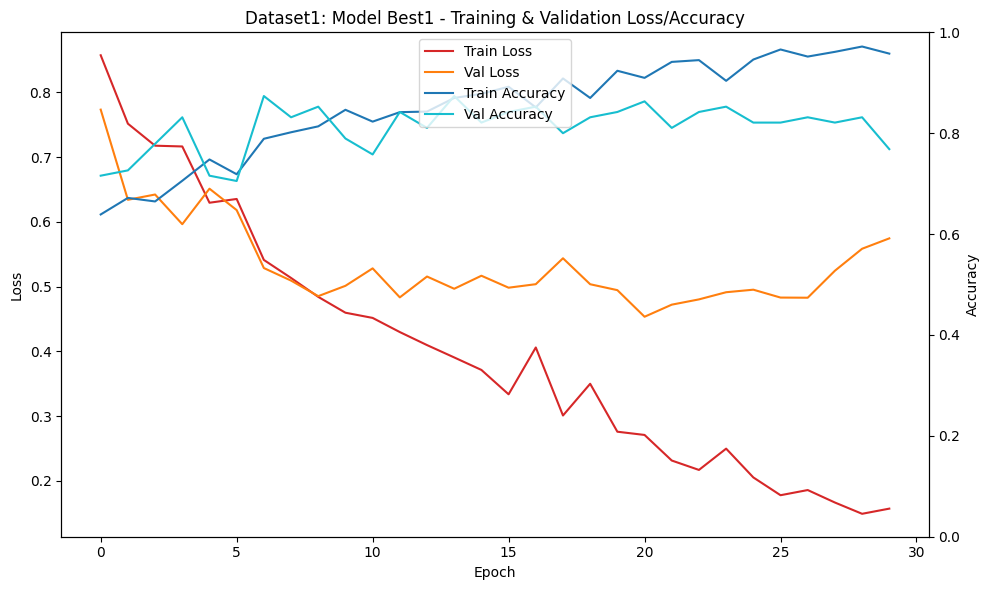

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history_model1.history)  # history_model1 from fit

plt.figure(figsize=(10,6))

# loss
ax1 = plt.gca()
ax1.plot(history_df['loss'], label='Train Loss', color='tab:red')
ax1.plot(history_df['val_loss'], label='Val Loss', color='tab:orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.tick_params(axis='y')

# accuracy
ax2 = ax1.twinx()
ax2.plot(history_df['accuracy'], label='Train Accuracy', color='tab:blue')
ax2.plot(history_df['val_accuracy'], label='Val Accuracy', color='tab:cyan')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title("Dataset1: Model Best1 - Training & Validation Loss/Accuracy")
plt.tight_layout()
plt.savefig("loss_accuracy_model_best1.png", dpi=300)
plt.show()


# **Dataset 2:** without any changes


In [63]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (948, 3, 128, 128)
X_test shape: (238, 3, 128, 128)
y_train shape: (948,)
y_test shape: (238,)


Callback: Early stopping

In [ ]:
if os.path.exists('checkpoints_best_only/checkpoint_model2.weights.h5'):
    os.remove('checkpoints_best_only/checkpoint_model2.weights.h5') #overwrite old saved callbacks to start with 0 for validation loss

checkpoint_best_only = ModelCheckpoint(
    filepath='checkpoints_best_only/checkpoint_model2.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    verbose=1) #only for visibility during running

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1) #effective stopping after 5 epochs without improvement

callbacks = [checkpoint_best_only, early_stop]

CNN final model 2 to train


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# VGG16-Basis
conv_base = VGG16(
    include_top=False,
    input_shape=input_img_shape)
for layer in conv_base.layers:
    layer.trainable = False

# Model with best Hyperparameters
model_best2 = Sequential([
    conv_base,
    Flatten(),
    Dropout(dropout1_best),
    Dense(256, activation="relu"),
    Dropout(dropout2_best),
    Dense(4, activation="softmax")])

model_best2.compile(
    optimizer=Adam(learning_rate=lr_best),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


In [24]:
history = model_best2.fit(
    X_train_trans,            #original data
    y_train_relabeled,
    validation_split=0.1,   # validation intern
    epochs=100,
    batch_size=batch_size_best,
    callbacks=callbacks,
    verbose=1)


Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4487 - loss: 1.2661
Epoch 1: val_accuracy improved from -inf to 0.77895, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.4507 - loss: 1.2617 - val_accuracy: 0.7789 - val_loss: 0.6843
Epoch 2/100
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6966 - loss: 0.7082
Epoch 2: val_accuracy did not improve from 0.77895
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6974 - loss: 0.7071 - val_accuracy: 0.7684 - val_loss: 0.6564
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7161 - loss: 0.6524
Epoch 3: val_accuracy improved from 0.77895 to 0.78947, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7162 - loss: 0.6521 - val_accuracy: 0.7895 - val_loss: 0.6004
Epoch 4/100
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7813 - loss: 0.5575
Epoch 4: val

In [ ]:
model_best2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,009,998 (80.15 MB)

 Trainable params: 2,098,436 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 4,196,874 (16.01 MB)

# Evaluation on test set

Metrics

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# ============================
# 1) TRAINING METRICS
# ============================
y_train_pred = model_best2.predict(X_train_trans).argmax(axis=1)

train_f1 = f1_score(y_train_relabeled, y_train_pred, average='weighted')
train_precision = precision_score(y_train_relabeled, y_train_pred, average='weighted')
train_recall = recall_score(y_train_relabeled, y_train_pred, average='weighted')

train_loss, train_acc = model_best2.evaluate(X_train_trans, y_train_relabeled, verbose=0)

print("\n=== TRAIN METRICS ===")
print(f"Train loss: {train_loss:.4f}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Train weighted F1: {train_f1:.4f}")
print(f"Train precision (weighted): {train_precision:.4f}")
print(f"Train recall (weighted): {train_recall:.4f}")

# ============================
# 2) VALIDATION METRICS
# ============================
val_size = int(0.1 * len(X_train_trans))
X_val = X_train_trans[-val_size:]
y_val = y_train_relabeled[-val_size:]

y_val_pred = model_best2.predict(X_val).argmax(axis=1)

val_f1 = f1_score(y_val, y_val_pred, average='weighted')
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')

val_loss, val_acc = model_best2.evaluate(X_val, y_val, verbose=0)

print("\n=== VALIDATION METRICS ===")
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation weighted F1: {val_f1:.4f}")
print(f"Validation precision (weighted): {val_precision:.4f}")
print(f"Validation recall (weighted): {val_recall:.4f}")

# ============================
# 3) TEST METRICS
# ============================
y_test_pred = model_best2.predict(X_test_trans).argmax(axis=1)

test_f1_ds2 = f1_score(y_test_relabeled, y_test_pred, average='weighted')
test_precision_ds2 = precision_score(y_test_relabeled, y_test_pred, average='weighted')
test_recall_ds2 = recall_score(y_test_relabeled, y_test_pred, average='weighted')

test_loss_ds2, test_acc_ds2 = model_best2.evaluate(X_test_trans, y_test_relabeled, verbose=0)

print("\n=== TEST METRICS ===")
print(f"Test loss: {test_loss_ds2:.4f}")
print(f"Test accuracy: {test_acc_ds2:.4f}")
print(f"Test weighted F1: {test_f1_ds2:.4f}")
print(f"Test precision (weighted): {test_precision_ds2:.4f}")
print(f"Test recall (weighted): {test_recall_ds2:.4f}")


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step

=== TRAIN METRICS ===
Train loss: 0.1990
Train accuracy: 0.9578
Train weighted F1: 0.9578
Train precision (weighted): 0.9580
Train recall (weighted): 0.9578
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

=== VALIDATION METRICS ===
Validation loss: 0.4922
Validation accuracy: 0.8511
Validation weighted F1: 0.8520
Validation precision (weighted): 0.8624
Validation recall (weighted): 0.8511
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 512ms/step

=== TEST METRICS ===
Test loss: 0.5418
Test accuracy: 0.8319
Test weighted F1: 0.8313
Test precision (weighted): 0.8326
Test recall (weighted): 0.8319


Loss - accuracy curve

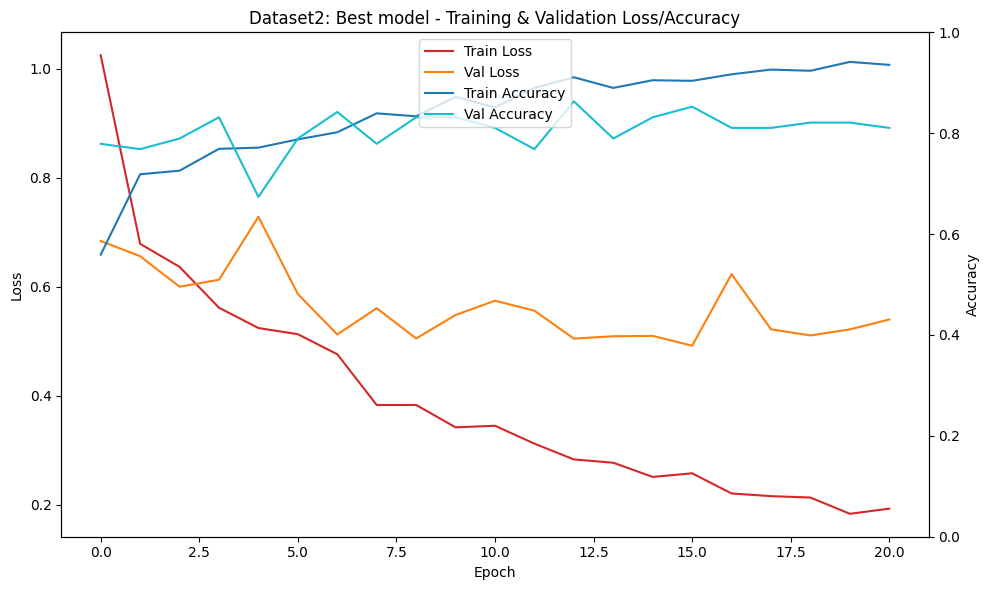

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# History in DataFrame konvertieren
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10,6))

# Achse 1 (links): Loss
ax1 = plt.gca()
ax1.plot(history_df['loss'], label='Train Loss', color='tab:red')
ax1.plot(history_df['val_loss'], label='Val Loss', color='tab:orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.tick_params(axis='y')

# Zweite Achse (rechts): Accuracy
ax2 = ax1.twinx()
ax2.plot(history_df['accuracy'], label='Train Accuracy', color='tab:blue')
ax2.plot(history_df['val_accuracy'], label='Val Accuracy', color='tab:cyan')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

# Gemeinsame Legende
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title("Dataset2: Best model - Training & Validation Loss/Accuracy")
plt.tight_layout()
plt.savefig("loss_accuracy_best_model.png", dpi=300)
plt.show()


# **Dataset 3:** Data augmentation on training set


Train - validation split for final model (for early stopping and augmentation only on training set)

In [65]:
X_train_ds3, X_val_ds3, y_train_ds3, y_val_ds3 = train_test_split(
    X_train_trans, y_train_relabeled, test_size=0.2, random_state=5, stratify=y_train_relabeled)

In [66]:

print("X_train_ds3 shape:", X_train_ds3.shape)
print("X_val_ds3 shape:", X_val_ds3.shape)
print("y_train_ds3 shape:", y_train_ds3.shape)
print("y_val_ds3 shape:", y_val_ds3.shape)

X_train_ds3 shape: (758, 128, 128, 3)
X_val_ds3 shape: (190, 128, 128, 3)
y_train_ds3 shape: (758,)
y_val_ds3 shape: (190,)


Augmentation on training set

In [67]:
import albumentations as A

train_transform = A.Compose([
    A.RandomRotate90(p=1.0), #p = 1 -> augmentation on all images
    A.RandomBrightnessContrast(0.05, 0.05, p=1.0),
    A.GaussNoise(var=(5,20), p=1.0)])


/tmp/ipython-input-3751624760.py:6: UserWarning: Argument(s) 'var' are not valid for transform GaussNoise
  A.GaussNoise(var=(5,20), p=1.0)])


In [68]:
#function for augmentation
def augment_dataset(X, times=3):
    X_augmented = [X.copy()]
    for _ in range(times):
        X_batch = np.empty_like(X)
        for i in range(len(X)):
            img = X[i].astype(np.uint8)
            X_batch[i] = train_transform(image=img)['image']
        X_augmented.append(X_batch.copy())
    return np.concatenate(X_augmented, axis=0)


In [69]:
X_train_aug_ds3 = augment_dataset(X_train_ds3, times=3)
y_train_aug_ds3 = np.tile(y_train_ds3, 4)  # duplicate labels: 1 Original + 3 Augmentations

print("Augmented dataset shape:", X_train_aug_ds3.shape)
print("Augmented labels shape:", y_train_aug_ds3.shape)  # 3032 (-> 758 + (3*758 augmemntations))


Augmented dataset shape: (3032, 128, 128, 3)
Augmented labels shape: (3032,)


Callback: Early stopping

In [75]:
if os.path.exists('checkpoints_best_only/checkpoint_model2.weights.h5'):
    os.remove('checkpoints_best_only/checkpoint_model2.weights.h5') #overwrite old saved callbacks to start with 0 for validation loss

checkpoint_best_only = ModelCheckpoint(
    filepath='checkpoints_best_only/checkpoint_model2.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    verbose=1) #only for visibility during running

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1) #effective stopping after 5 epochs without improvement

callbacks = [checkpoint_best_only, early_stop]

Final Model 3 for training

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# VGG16-Basis
conv_base = VGG16(
    include_top=False,
    input_shape=input_img_shape)
for layer in conv_base.layers:
    layer.trainable = False


# Model with best Hyperparameters
model_best3 = Sequential([
    conv_base,
    Flatten(),
    Dropout(dropout1_best),
    Dense(256, activation="relu"),
    Dropout(dropout2_best),
    Dense(4, activation="softmax")])

model_best3.compile(
    optimizer=Adam(learning_rate=lr_best),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


In [77]:
history = model_best3.fit(
    X_train_aug_ds3,
    y_train_aug_ds3,
        validation_data=(X_val_ds3, y_val_ds3),
    epochs=100,
    batch_size=batch_size_best,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3148 - loss: 2.9427
Epoch 1: val_accuracy improved from -inf to 0.69474, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.3149 - loss: 2.9371 - val_accuracy: 0.6947 - val_loss: 0.8254
Epoch 2/100
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3928 - loss: 1.2349
Epoch 2: val_accuracy improved from 0.69474 to 0.72632, saving model to checkpoints_best_only/checkpoint_model2.weights.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3929 - loss: 1.2347 - val_accuracy: 0.7263 - val_loss: 0.6963
Epoch 3/100
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4120 - loss: 1.2034
Epoch 3: val_accuracy did not improve from 0.72632
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.4121 - loss: 1.2033 - val_accuracy: 0.7263 - val_loss: 0.6995
Epoch 4/100
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4279 - loss: 1.1676

Metrics and evaluation on test set

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# ============================
# 1) TRAINING METRICS
# ============================
y_train_pred_ds3 = model_best3.predict(X_train_aug_ds3).argmax(axis=1)

train_f1_ds3 = f1_score(y_train_aug_ds3, y_train_pred_ds3, average='weighted')
train_precision_ds3 = precision_score(y_train_aug_ds3, y_train_pred_ds3, average='weighted')
train_recall_ds3 = recall_score(y_train_aug_ds3, y_train_pred_ds3, average='weighted')

train_loss_ds3, train_acc_ds3 = model_best3.evaluate(X_train_aug_ds3, y_train_aug_ds3, verbose=0)

print("\n=== TRAIN METRICS ===")
print(f"Train loss: {train_loss_ds3:.4f}")
print(f"Train accuracy: {train_acc_ds3:.4f}")
print(f"Train weighted F1: {train_f1_ds3:.4f}")
print(f"Train precision (weighted): {train_precision_ds3:.4f}")
print(f"Train recall (weighted): {train_recall_ds3:.4f}")

# ============================
# 2) VALIDATION METRICS
# ============================
y_val_pred_ds3 = model_best3.predict(X_val_ds3).argmax(axis=1)

val_f1_ds3 = f1_score(y_val_ds3, y_val_pred_ds3, average='weighted')
val_precision_ds3 = precision_score(y_val_ds3, y_val_pred_ds3, average='weighted')
val_recall_ds3 = recall_score(y_val_ds3, y_val_pred_ds3, average='weighted')

val_loss_ds3, val_acc_ds3 = model_best3.evaluate(X_val_ds3, y_val_ds3, verbose=0)

print("\n=== VALIDATION METRICS ===")
print(f"Validation loss: {val_loss_ds3:.4f}")
print(f"Validation accuracy: {val_acc_ds3:.4f}")
print(f"Validation weighted F1: {val_f1_ds3:.4f}")
print(f"Validation precision (weighted): {val_precision_ds3:.4f}")
print(f"Validation recall (weighted): {val_recall_ds3:.4f}")

# ============================
# 3) TEST METRICS
# ============================
y_test_pred_ds3 = model_best3.predict(X_test_trans).argmax(axis=1)

test_f1_ds3 = f1_score(y_test_relabeled, y_test_pred_ds3, average='weighted')
test_precision_ds3 = precision_score(y_test_relabeled, y_test_pred_ds3, average='weighted')
test_recall_ds3 = recall_score(y_test_relabeled, y_test_pred_ds3, average='weighted')

test_loss_ds3, test_acc_ds3 = model_best3.evaluate(X_test_trans, y_test_relabeled, verbose=0)

print("\n=== TEST METRICS ===")
print(f"Test loss: {test_loss_ds3:.4f}")
print(f"Test accuracy: {test_acc_ds3:.4f}")
print(f"Test weighted F1: {test_f1_ds3:.4f}")
print(f"Test precision (weighted): {test_precision_ds3:.4f}")
print(f"Test recall (weighted): {test_recall_ds3:.4f}")


95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step

=== TRAIN METRICS ===
Train loss: 1.0923
Train accuracy: 0.4693
Train weighted F1: 0.4224
Train precision (weighted): 0.7459
Train recall (weighted): 0.4693
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step

=== VALIDATION METRICS ===
Validation loss: 0.6312
Validation accuracy: 0.7421
Validation weighted F1: 0.7385
Validation precision (weighted): 0.7396
Validation recall (weighted): 0.7421
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step

=== TEST METRICS ===
Test loss: 0.5730
Test accuracy: 0.8109
Test weighted F1: 0.8101
Test precision (weighted): 0.8107
Test recall (weighted): 0.8109


Loss - accuracy curve

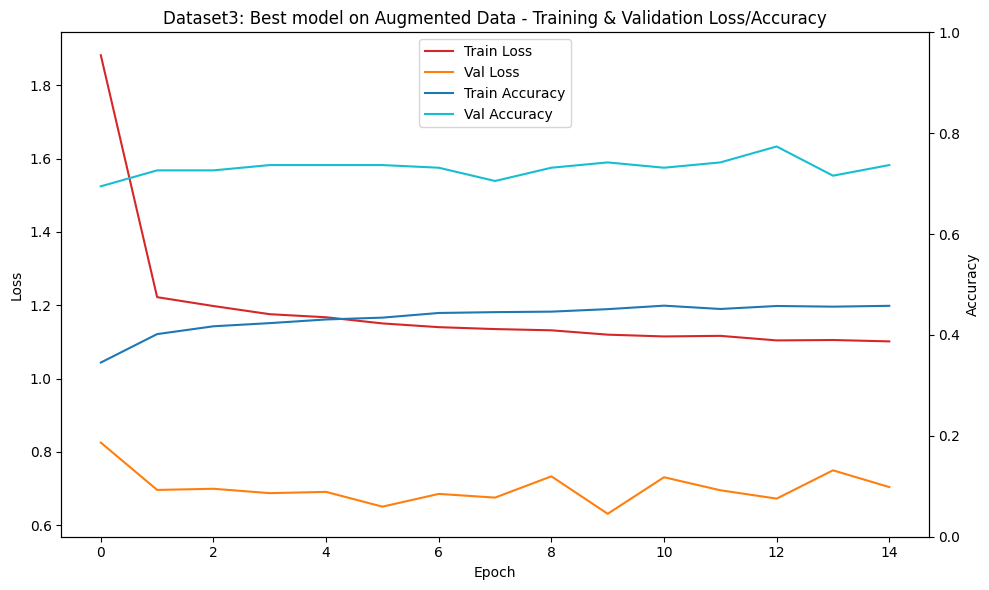

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)  # history = model_best3.fit(...)

plt.figure(figsize=(10,6))

#Loss
ax1 = plt.gca()
ax1.plot(history_df['loss'], label='Train Loss', color='tab:red')
ax1.plot(history_df['val_loss'], label='Val Loss', color='tab:orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.tick_params(axis='y')

# Accuracy
ax2 = ax1.twinx()
ax2.plot(history_df['accuracy'], label='Train Accuracy', color='tab:blue')
ax2.plot(history_df['val_accuracy'], label='Val Accuracy', color='tab:cyan')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

#Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title("Dataset3: Best model on Augmented Data - Training & Validation Loss/Accuracy")
plt.tight_layout()
plt.savefig("loss_accuracy_best_model_ds3.png", dpi=300)
plt.show()


# Comparison of performances:

In [100]:
print(f"logistic regression")
print(f"Accuracy: {clf_acc_test:.4f}")
print(f"Log-Loss: {test_logloss:.4f}")
print(f"Weighted F1 Score: {clf_f1_test:.4f}")
print(" ")
print(f"CNN simple model")
print(f"Test accuracy: {test_acc_sm:.4f}")
print(f"Test loss: {test_loss_sm:.4f}")
print(f"Test weighted F1: {test_f1_sm:.4f}")
print(" ")
print(f"CNN final model 1 (subdivided images)")
print(f"Test accuracy: {test_acc_ds1:.4f}")
print(f"Test loss: {test_loss_ds1:.4f}")
print(f"Test weighted F1: {test_f1_ds1:.4f}")
print(" ")
print(f"CNN final model 2 (original dataset)")
print(f"Test accuracy: {test_acc_ds2:.4f}")
print(f"Test loss: {test_loss_ds2:.4f}")
print(f"Test weighted F1: {test_f1_ds2:.4f}")
print(" ")
print(f"CNN final model 3 (augmented dataset)")
print(f"Test accuracy: {test_acc_ds3:.4f}")
print(f"Test loss: {test_loss_ds3:.4f}")
print(f"Test weighted F1: {test_f1_ds3:.4f}")

logistic regression
Accuracy: 0.5294
Log-Loss: 1.3784
Weighted F1 Score: 0.5292
 
CNN simple model
Test accuracy: 0.7353
Test loss: 0.6741
Test weighted F1: 0.7328
 
CNN final model 1 (subdivided images)


NameError: name 'test_acc_ds1' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = [
    "Logistic Regression",
    "CNN Simple model",
    "CNN Dataset 1",
    "CNN Dataset 2",
    "CNN Dataset 3"]

# Accuracy
accuracies = [clf_acc_test, test_acc_sm, test_acc_ds1, test_acc_ds2, test_acc_ds3]

# Weighted F1
f1_scores = [clf_f1_test, test_f1_sm, test_f1_ds1, test_f1_ds2, test_f1_ds3]

# Loss
losses = [test_logloss, test_loss_sm, test_loss_ds1, test_loss_ds2, test_loss_ds3]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width/2, accuracies, width, label='Accuracy', color='tab:blue')
plt.bar(x + width/2, f1_scores, width, label='Weighted F1', color='tab:green')

ax2 = plt.gca().twinx()
ax2.plot(x, losses, color='tab:red', marker='o', label='Loss')
ax2.set_ylabel('Loss')

plt.xticks(x, models, rotation=15)
plt.ylabel('Score (Accuracy / F1)')
plt.title('Comparison of Models on Test Set')
plt.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


# Confusion matrix and xAI of the model with the best performance: the original dataset

Confusion Matrix

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step


<Figure size 600x500 with 0 Axes>

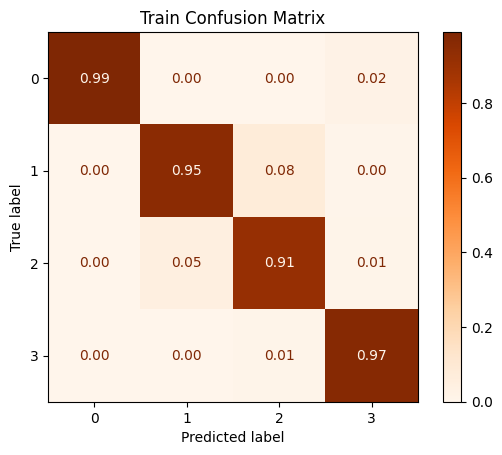

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


<Figure size 600x500 with 0 Axes>

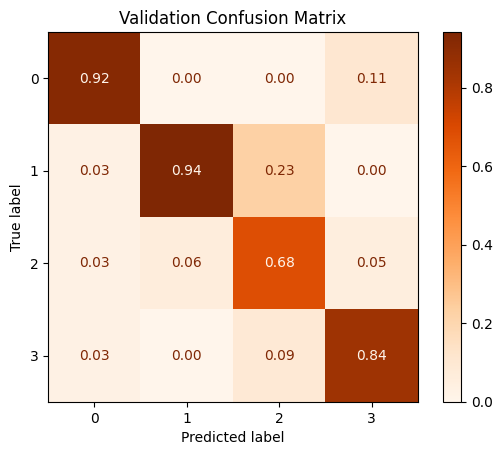

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


<Figure size 600x500 with 0 Axes>

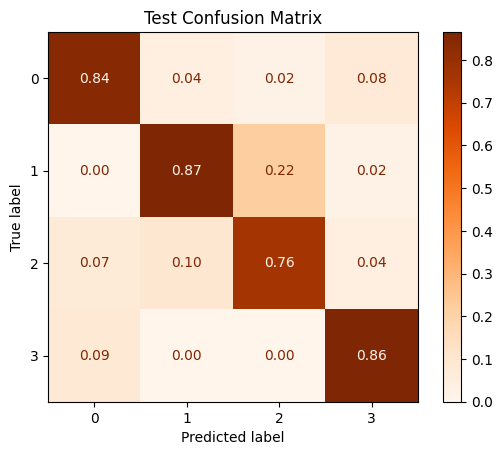

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1) TRAIN CONFUSION MATRIX
# ============================
train_preds = model_best2.predict(X_train_trans)
train_preds = np.argmax(train_preds, axis=1)

cm_train = confusion_matrix(y_train_relabeled, train_preds, normalize="pred")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=np.unique(y_train_relabeled))

plt.figure(figsize=(6,5))
disp_train.plot(cmap=plt.cm.Oranges, values_format=".2f")
plt.title("Dataset 2: Train Confusion Matrix")
plt.show()

# ============================
# 2) VALIDATION CONFUSION MATRIX
# ============================
val_preds = model_best2.predict(X_val)
val_preds = np.argmax(val_preds, axis=1)

cm_val = confusion_matrix(y_val, val_preds, normalize="pred")
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=np.unique(y_val))

plt.figure(figsize=(6,5))
disp_val.plot(cmap=plt.cm.Oranges, values_format=".2f")
plt.title("Dataset 2: Validation Confusion Matrix")
plt.show()

# ============================
# 3) TEST CONFUSION MATRIX
# ============================
test_preds = model_best2.predict(X_test_trans)
test_preds = np.argmax(test_preds, axis=1)

cm_test = confusion_matrix(y_test_relabeled, test_preds, normalize="pred")
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=np.unique(y_test_relabeled))

plt.figure(figsize=(6,5))
disp_test.plot(cmap=plt.cm.Oranges, values_format=".2f")
plt.title("Dataset 2: Test Confusion Matrix")
plt.show()


Saliency maps

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


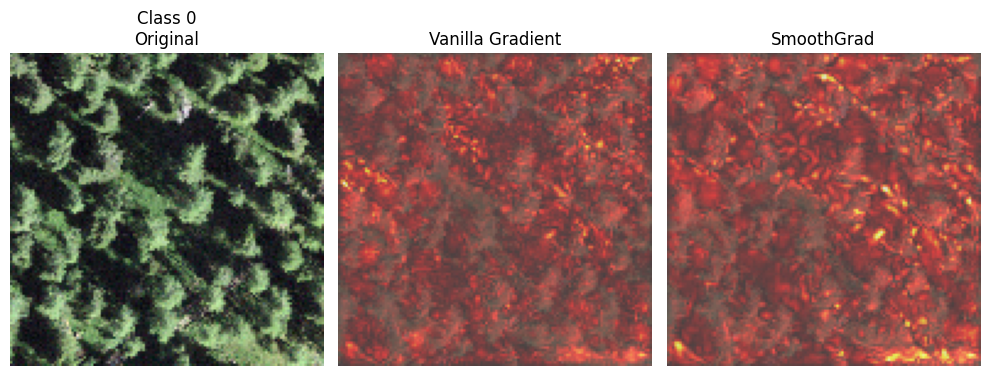

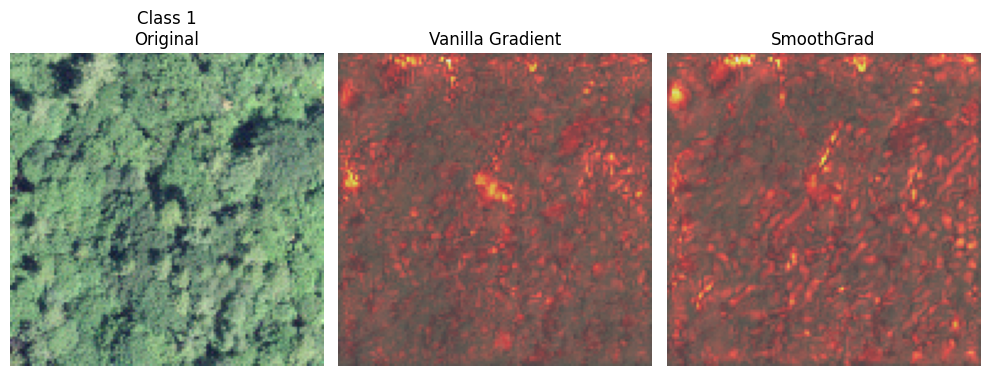

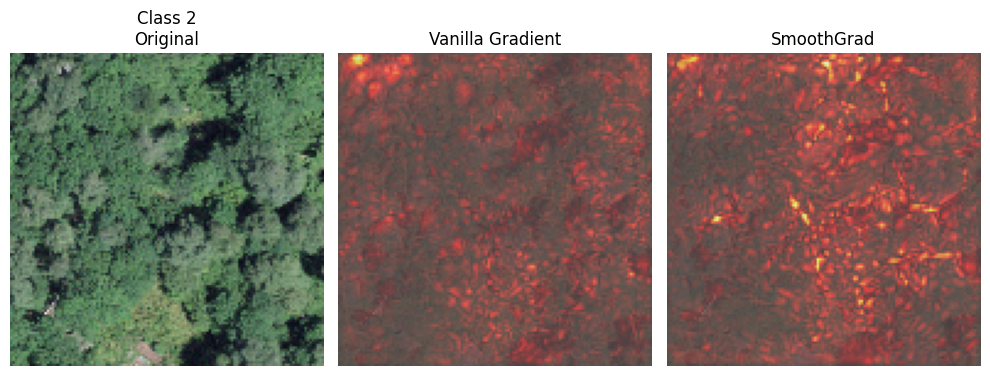

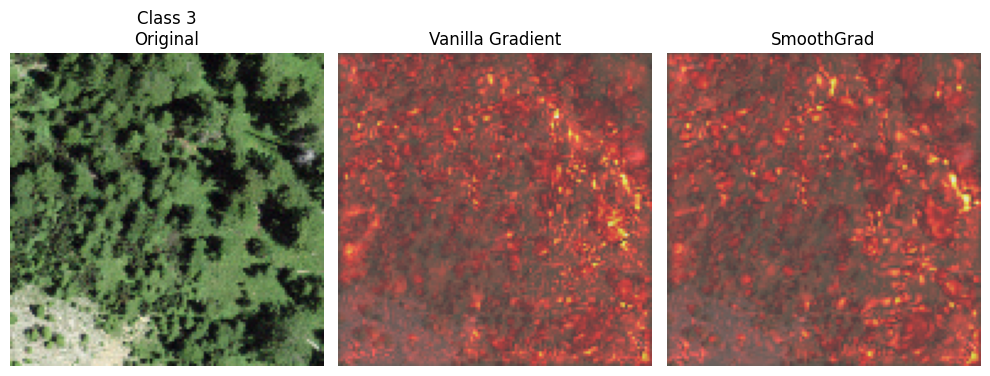

In [ ]:
import tensorflow as tf

# Anzahl der Klassen
num_classes = len(np.unique(y_test_relabeled))

# SmoothGrad Funktion
def smoothgrad(model, img_tensor, label, n_samples=50, noise_level=0.1):
    avg_grad = 0
    for _ in range(n_samples):
        noise = tf.random.normal(shape=img_tensor.shape, mean=0.0, stddev=noise_level)
        noisy_img = img_tensor + noise
        with tf.GradientTape() as tape:
            tape.watch(noisy_img)
            preds = model(noisy_img)
            loss = preds[0, label]
        grads = tape.gradient(loss, noisy_img)
        avg_grad += grads
    avg_grad /= n_samples
    saliency = tf.reduce_max(tf.abs(avg_grad), axis=-1)[0]
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency))
    return saliency

# Vorhersagen auf Testset
y_test_pred = model_best2.predict(X_test_trans).argmax(axis=1)

# Für jede Klasse das erste korrekt vorhergesagte Bild auswählen
for cls in range(num_classes):
    correct_idx = np.where((y_test_pred == y_test_relabeled) & (y_test_relabeled == cls))[0]
    if len(correct_idx) == 0:
        print(f"No correct predictions for class {cls}")
        continue

    idx = correct_idx[0]
    img = X_test_trans[idx:idx+1]  # Shape: (1,H,W,C)
    label = y_test_relabeled[idx]

    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    img_tensor = tf.Variable(img_tensor)

    # Vanilla Gradient
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model_best2(img_tensor)
        loss = preds[0, label]
    grads = tape.gradient(loss, img_tensor)
    vanilla_saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    vanilla_saliency = (vanilla_saliency - tf.reduce_min(vanilla_saliency)) / (tf.reduce_max(vanilla_saliency) - tf.reduce_min(vanilla_saliency))

    # SmoothGrad
    smooth_saliency = smoothgrad(model_best2, img_tensor, label)

    # Originalbild für Anzeige
    orig = ((img[0] - img[0].min()) / (img[0].max() - img[0].min()) * 255).astype(np.uint8)

    # Plot
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(orig)
    plt.title(f"Class {cls}\nOriginal")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(orig, alpha=0.4)
    plt.imshow(vanilla_saliency, cmap='hot', alpha=0.6)
    plt.title("Vanilla Gradient")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(orig, alpha=0.4)
    plt.imshow(smooth_saliency, cmap='hot', alpha=0.6)
    plt.title("SmoothGrad")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
